# PEA-STA Analysis

In [9]:
cd /home/mscs/congfeng4/GuidedStudy/Code/SCOIT/

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [10]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'PEA_STA'
FEATURE = 'walk'
embedding_dir = f'./embeddings/{DATA}'

In [11]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [13]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['u3035_0h_contol_A02', 'u3035_0h_contol_A03',
       'u3035_0h_contol_A04', 'u3035_0h_contol_A05',
       'u3035_0h_contol_A06', 'u3035_0h_contol_A07',
       'u3035_0h_contol_A08', 'u3035_0h_contol_A09',
       'u3035_0h_contol_A10', 'u3035_0h_contol_A11',
       'u3035_0h_contol_A12', 'u3035_0h_contol_B02',
       'u3035_0h_contol_B03', 'u3035_0h_contol_B04',
       'u3035_0h_contol_B05', 'u3035_0h_contol_B06',
       'u3035_0h_contol_B07', 'u3035_0h_contol_B08',
       'u3035_0h_contol_B09', 'u3035_0h_contol_B10',
       'u3035_0h_contol_B11', 'u3035_0h_contol_B12',
       'u3035_0h_contol_C02', 'u3035_0h_contol_C03',
       'u3035_0h_contol_C04', 'u3035_0h_contol_C05',
       'u3035_0h_contol_C06', 'u3035_0h_contol_C08',
       'u3035_0h_contol_C09', 'u3035_0h_contol_C10',
       'u3035_0h_contol_C11', 'u3035_0h_contol_C12',
       'u3035_0h_contol_D01', 'u3035_0h_contol_D02',
       'u3035_0h_contol_D03', 'u3035_0h_contol_D05',
       'u3035_0h_contol_D06', 'u3035_0h_contol

In [14]:
def find_cell_stage(cell_id):
    if '0h' in cell_id:
        return '0h untreated'
    if '6d' in cell_id:
        if 'contol' in cell_id:
            return '6d untreated'
        if 'BMP4' in cell_id:
            return '6d BMP4 treated'
    raise ValueError(cell_id)

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [15]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

In [16]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

166

## A. Cell Embeddings UMAP

Text(0, 0.5, 'UMAP_2')

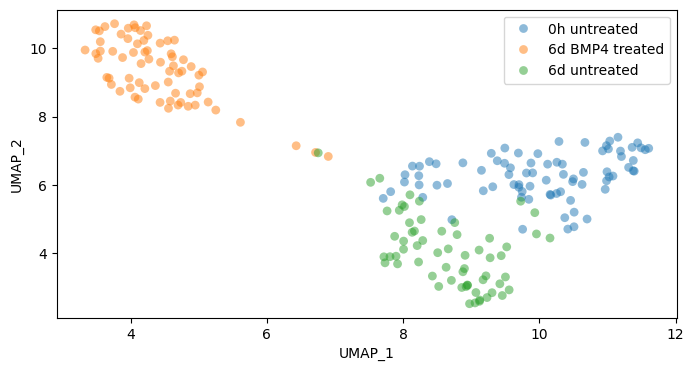

In [17]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id,
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


In [18]:
EXPR_LIST = [
    "1D1", "1D2", "SNAL1", "TUBB3"
]
import re
GENE_RE = re.compile('|'.join(EXPR_LIST))

In [19]:
gene_list = [
    "CAV1", "SOD1", "GFAP", "CASP8", "IKBKG", "VIM", "SMAD4", "CDKN1B",
    "PXN", "MIF", "SOD2", "ID1", "SOX2", "MELK", "PLAU", "XIAP", "PLCG1",
    "EGF", "TGFB1", "EGFR", "CDKN2C", "MKI67", "NPM1", "ERBB2", "EPHA2"
]


In [20]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AKT1_expr,AXIN2_expr,BAX_expr,BCL2_expr,BCL2L1_expr,BMI1_expr,BMP2_expr,BMP4_expr,BMPR1A_expr,BMPR1B_expr,...,SOX9_protein,TENASCIN.C_protein,TGFB1_protein,THY1_protein,TNFRSF10B_protein,TNFRSF1A_protein,TP53_protein,VEGFA_protein,VIM_protein,XIAP_protein
0,5.047740,0.840485,0.237452,-1.438898,0.899535,-0.028335,-0.588438,0.715894,-0.078673,1.253434,...,0.841761,0.167438,0.951970,-1.071267,-1.264835,-0.670440,0.906303,-0.042133,-0.116779,-0.198109
1,1.083639,0.532566,0.323056,-5.268723,-0.017439,-0.194474,0.239168,0.466960,0.309654,-0.011941,...,0.776089,0.223956,0.506996,1.158296,0.481230,0.759229,0.731251,0.284598,0.176089,1.133638
2,-3.292462,-0.358353,-0.397135,-0.394050,0.515547,-0.572693,-0.169294,-1.277622,0.033715,-0.740017,...,0.635331,0.491593,0.630702,-1.593951,-1.002561,-1.706474,-0.322461,-0.547682,0.401113,-1.195604
3,2.067062,0.199445,0.045443,5.308474,-0.250057,-0.187092,0.356227,0.353872,-0.003844,0.517723,...,-0.728339,-0.480607,-0.335753,0.194904,0.774639,1.498142,0.180757,0.716520,-0.615431,0.696166
4,4.658889,-0.056179,-0.152565,3.939234,-0.004200,-0.278679,-0.228399,-0.517591,-0.118013,-0.377715,...,0.146557,-0.054078,0.163300,-0.293331,-0.340629,-0.476491,-0.221423,-0.283171,0.163422,-0.242750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-4.351845,-0.029822,0.182387,0.006465,0.923624,0.367515,-0.647099,-0.237548,-0.638933,0.755214,...,0.785640,0.719252,-0.875442,1.865407,-0.145906,-0.144538,0.208071,-0.142374,1.286775,2.435825
60,-3.727449,0.699503,0.688379,-2.825875,0.246684,0.236607,0.743132,1.195573,-0.028012,0.857335,...,-0.109080,-0.080483,-0.483462,0.953819,1.791496,1.697385,0.611898,0.105274,-0.426416,0.534815
61,9.387176,-0.269081,-0.261197,3.572889,-0.419031,-0.290836,-0.108386,-0.461019,0.027230,-0.100402,...,-0.062694,-0.178232,-0.408070,0.733705,-0.031390,-0.114648,-0.056315,0.030423,-0.137886,0.195506
62,-3.386947,-0.422818,-0.037145,2.714758,0.019544,-0.555742,-0.683104,-0.971920,-0.029091,-0.225658,...,-0.174902,-0.058109,0.101464,-1.024631,-0.874067,-1.523083,-0.436230,-0.635852,0.416141,-0.445797


## C. Protein and RNA correlations

In [21]:
omics_embeddings[0, :].shape

(64,)

In [22]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, gene_list] + omics_embeddings[0, :].reshape((-1, 1))

In [23]:
df_protein = df_gene.loc[:, df_gene.columns.str.endswith('_protein')].rename(lambda x: x.replace('_protein', ''), axis=1)
df_protein = df_protein.loc[:, gene_list] + omics_embeddings[1, :].reshape((-1, 1))

In [24]:
df_corr = df_expr.corrwith(df_protein, method='pearson')

Text(0.5, 0, 'Pearson correlation coefficients')

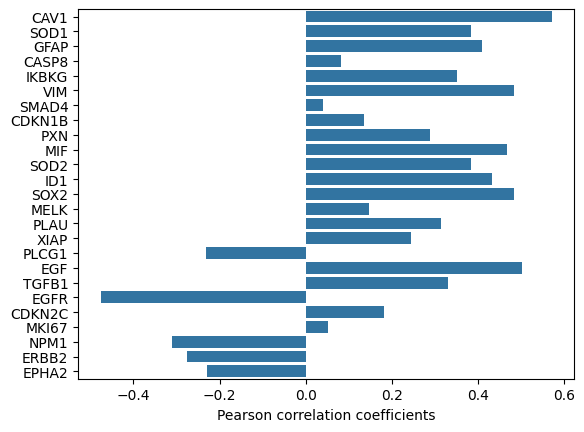

In [25]:
sns.barplot(df_corr, orient='h')
plt.xlabel('Pearson correlation coefficients')

In [26]:
df_cell = pd.DataFrame(cell_embeddings, index=cell_names)


Text(0.5, 1.0, 'CAV1')

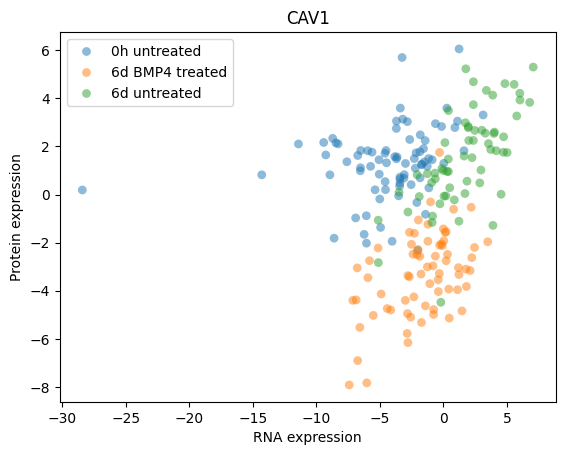

In [27]:
GENE = 'CAV1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'SOD1')

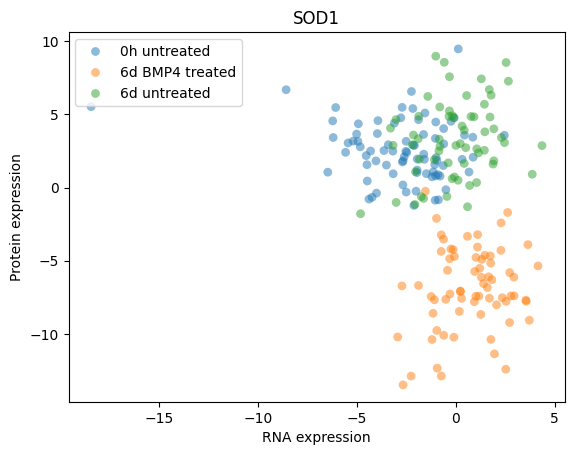

In [28]:
GENE = 'SOD1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'ERBB2')

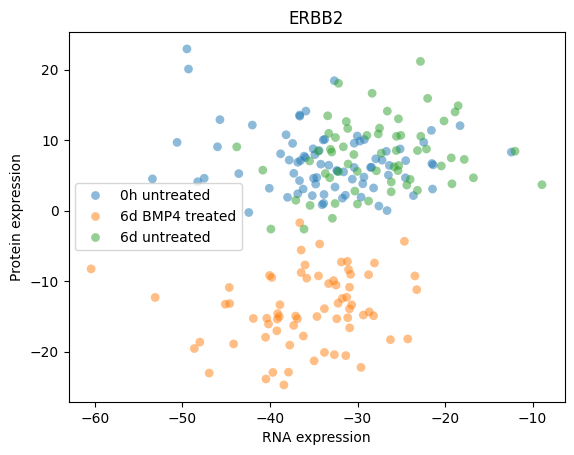

In [29]:
GENE = 'ERBB2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'EPHA2')

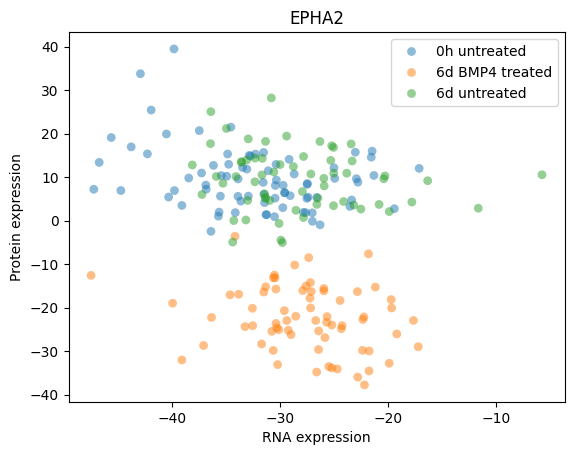

In [30]:
GENE = 'EPHA2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

## D. Gene embeddings on cells

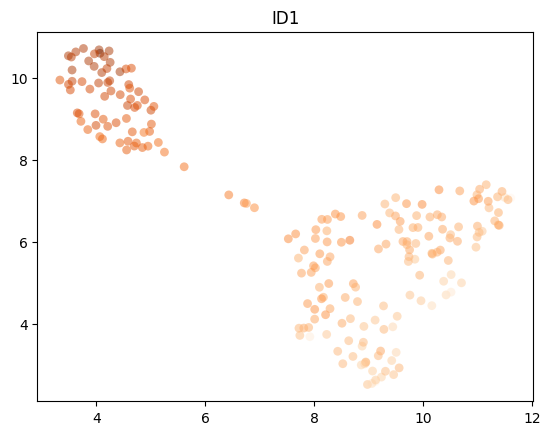

In [31]:
ID1_proj = df_cell @ df_protein['ID1'] + df_cell @ df_expr['ID1']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("ID1")
plt.legend().remove()

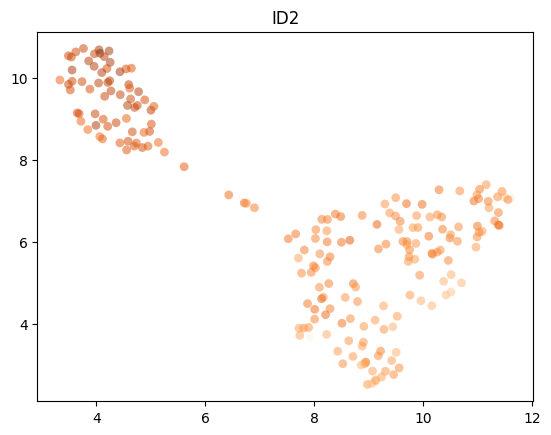

In [32]:
ID2_proj = df_cell @ df_gene['ID2_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID2_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("ID2")
plt.legend().remove()

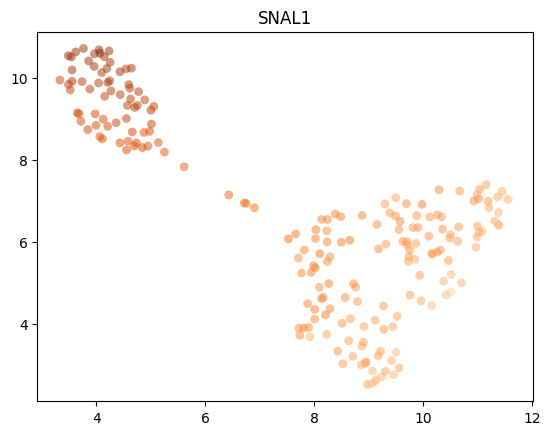

In [33]:
ID1_proj = df_cell @ df_gene['SNAL1_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("SNAL1")
plt.legend().remove()

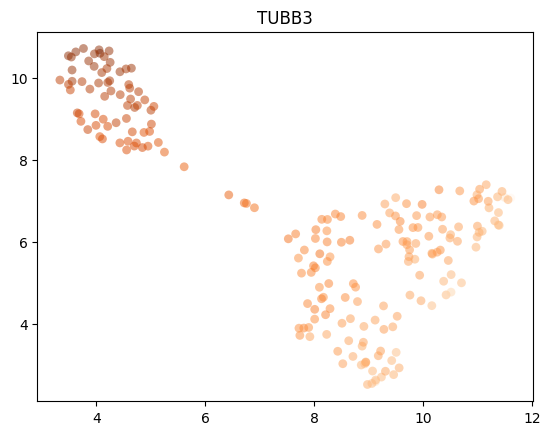

In [34]:
ID1_proj = df_cell @ df_gene['TUBB3_expr']

sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=ID1_proj,
                s=S, linewidth=0, alpha=0.5, palette='Oranges')
plt.xlabel("")
plt.ylabel("")
plt.title("TUBB3")
plt.legend().remove()

## Cell Clustering

In [35]:
from sklearn.cluster import k_means

cell_stage = set(cell_stage_from_id)

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings), n_clusters=len(cell_stage))
cluster.shape

(210,)

In [36]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}
cell_stage_ids

{'0h untreated': 0, '6d untreated': 1, '6d BMP4 treated': 2}

In [37]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [38]:
from scipy.optimize import linear_sum_assignment

def align_cluster(cluster_ids, y):
    kc = len(np.unique(cluster_ids))
    ky = len(np.unique(y))
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((kc, ky), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [39]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [40]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [42]:
y_pred_aligned = align_cluster(cluster, cell_stage_label)

In [44]:
metrics = compute_clustering_metrics(cell_stage_label, y_pred_aligned)
metrics


{'NMI': 0.7499293589492565,
 'ARI': 0.7800290627041273,
 'FMI': 0.8541052180788689}

### Baselines

t-SNE, PCA, UMAP.

In [45]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [46]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/PEA_STA/expression_data.csv',
        'protein': './data/PEA_STA/protein_data.csv',
    }, cell_key='Cells ', dataname='PEA_STA', prefix=Path('./data'))

In [47]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}
Load data done, time: 0.016295671463012695
Rename columns
Name: expr, Columns: Index(['AKT1_expr', 'APC_expr', 'APP_expr', 'AURKB_expr', 'AXIN1_expr',
       'AXIN2_expr', 'BAX_expr', 'BCL2_expr', 'BCL2L1_expr', 'BCL6_expr',
       ...
       'THY1_expr', 'TNFRSF10B_expr', 'TNFRSF1A_expr', 'TP53_expr',
       'TRADD_expr', 'TUBB3_expr', 'TWSG1_expr', 'VEGFA_expr', 'VIM_expr',
       'XIAP_expr'],
      dtype='object', length=141)
Name: protein, Columns: Index(['AKT1_protein', 'APC_protein', 'APP_protein', 'AURKB_protein',
       'AXIN1_protein', 'AXIN2_protein', 'BAX_protein', 'BCL2_protein',
       'BCL2L1_protein', 'BCL6_protein',
       ...
       'THY1_protein', 'TNFRSF10B_protein', 'TNFRSF1A_protein', 'TP53_protein',
       'TRADD_protein', 'TUBB3_protein', 'TWSG1_protein', 'VEGFA_protein',
       'VIM_protein', 'XIAP_protein'],
      dtype='object', length=1

In [48]:
assert (create.df.index == cell_names).all().all()


In [49]:
features = create.df.values
features.shape

(210, 166)

In [ ]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []
    k = len(np.unique(cell_stage_label))

    for name, method in baselines.items():
        print(name)
        if method is None:
            x = cell_embeddings
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


Text(0, 0.5, 'UMAP_2')

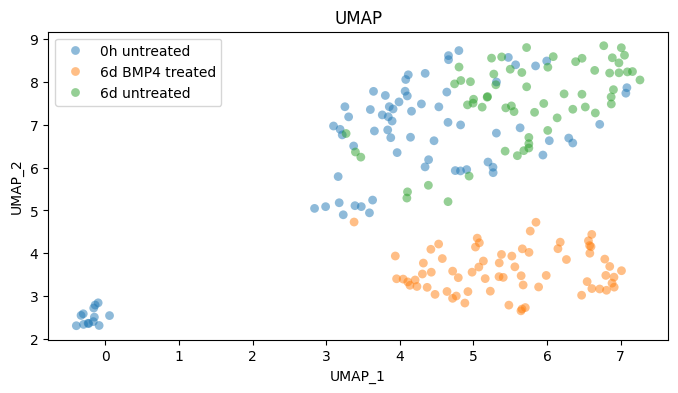

In [51]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

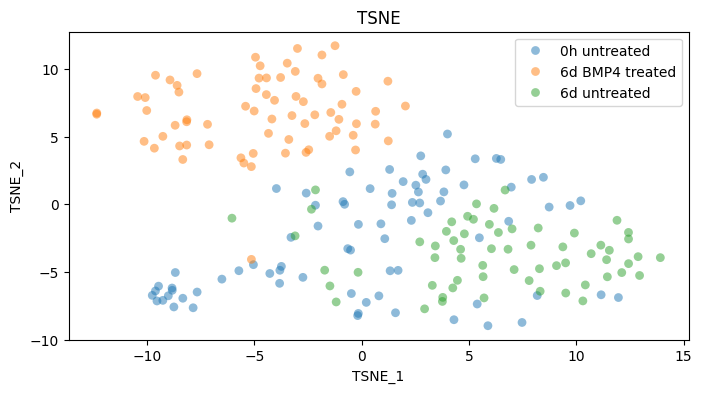

In [52]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")


### K-means performance

In [56]:
df_cluster = run_baselines(features, cell_embeddings)

TSNE


TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'

Text(0, 0.5, '')

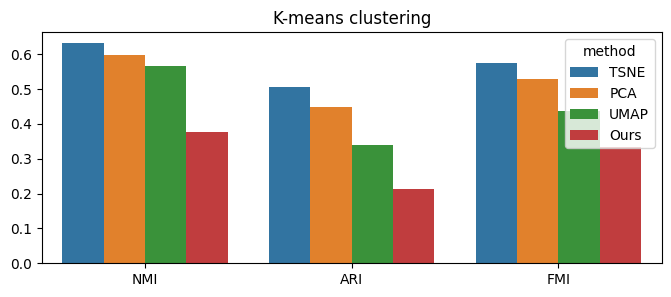

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

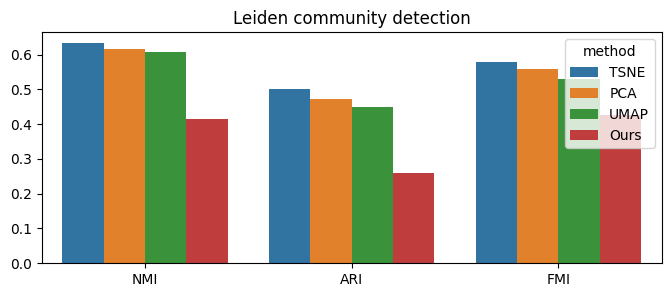

In [ ]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')